# Approach V5: 5. Model Evaluation & Comparison
**Project:** Honeywell Predictive Alerting Project - Tag: `03TIC_1023.PV` (Threshold: 21.0 °C)

This notebook evaluates the performance of the V5 models on the test set, computes detailed metrics, saves the consolidated comparison CSV, and generates comparative F1-score and KDE visualizations.

In [1]:
# Adjust working directory to project root if run from inside approch_v5 folder
import os
import sys
if os.path.basename(os.getcwd()) == 'approch_v5':
    os.chdir('..')
    print("Changed working directory to project root:", os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'approch_v5'))

Changed working directory to project root: D:\Python-2025\Antigravity\honeywell


In [2]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Defining Preprocessing & Split Boundaries

In [3]:
DEFAULT_DATA_PATH = r"d:\Python-2025\Antigravity\honeywell\03TIC_1023_PVHI\03TIC_1023_PVHI\03TIC_1023_Final_merged_TripDataRemoved.parquet"

def load_and_preprocess_data(file_path=DEFAULT_DATA_PATH, target_col="03TIC_1023.PV"):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"DCS Historian dataset not found at: {file_path}")
    df = pd.read_parquet(file_path)
    if 'TimeStamp' in df.columns:
        df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
        df = df.sort_values('TimeStamp').set_index('TimeStamp')
    elif not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1min')
    df = df.reindex(full_idx)
    df.index.name = 'TimeStamp'
    df = df.ffill(limit=5)
    return df

def get_alarm_based_split_boundaries(df, target_col="03TIC_1023.PV", threshold=21.0, split_ratio=[0.75, 0.125, 0.125]):
    is_alarm = (df[target_col] >= threshold).astype(int)
    alarm_group = (is_alarm == 0).cumsum()
    alarm_periods = df[is_alarm == 1].groupby(alarm_group)
    blocks = []
    for _, grp in alarm_periods:
        blocks.append((grp.index.min(), grp.index.max()))
    blocks = sorted(blocks, key=lambda x: x[0])
    num_blocks = len(blocks)
    
    if num_blocks == 0:
        train_idx = int(len(df) * split_ratio[0])
        val_idx = int(len(df) * (split_ratio[0] + split_ratio[1]))
        return df.index[train_idx], df.index[val_idx]
        
    train_count = int(np.ceil(num_blocks * split_ratio[0]))
    val_count = int(np.ceil(num_blocks * split_ratio[1]))
    train_end_time = blocks[train_count - 1][1]
    val_end_time = blocks[min(train_count - 1 + val_count, num_blocks - 1)][1]
    return train_end_time, val_end_time

## 2. Defining PyTorch Models

In [4]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1):
        super(LSTMRegressor, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

## 3. Defining Metric Calculations

In [5]:
def calculate_alert_metrics(actual_vals, predicted_vals, threshold=21.0):
    mae = mean_absolute_error(actual_vals, predicted_vals)
    rmse = np.sqrt(mean_squared_error(actual_vals, predicted_vals))
    actual_alarm = actual_vals >= threshold
    predicted_alarm = predicted_vals >= threshold
    tp = np.sum(actual_alarm & predicted_alarm)
    fp = np.sum((~actual_alarm) & predicted_alarm)
    fn = np.sum(actual_alarm & (~predicted_alarm))
    tn = np.sum((~actual_alarm) & (~predicted_alarm))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    
    return {
        "mae": mae,
        "rmse": rmse,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "far": far
    }

def plot_actual_vs_predicted_scenarios(timestamps, actual_vals, predicted_vals, threshold=21.0, title="Alarm Scenario Forecast", output_path="outputs/v5/alarm_scenario.png"):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.figure(figsize=(10, 5))
    plt.plot(timestamps, actual_vals, label="Actual Temperature", color="#0A1931", linewidth=1.5)
    plt.plot(timestamps, predicted_vals, label="Predicted Temperature", color="#0D9488", linestyle="--", linewidth=1.5)
    plt.axhline(y=threshold, color="#F96167", linestyle=":", label=f"Alarm Limit ({threshold} °C)", linewidth=1.2)
    plt.fill_between(timestamps, actual_vals, threshold, where=(actual_vals >= threshold), color="#F96167", alpha=0.15, label="Actual Alarm Event")
    plt.title(title, fontsize=12, fontweight='bold', color="#0A1931")
    plt.xlabel("Timeline", fontsize=10)
    plt.ylabel("Temperature (°C)", fontsize=10)
    plt.legend(loc="upper left")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

## 4. Load Selected Features and Splits

In [6]:
with open("models/v5/selected_features_v5.pkl", "rb") as f:
    selected_features = pickle.load(f)
with open("models/v5/scaler_v5.pkl", "rb") as f:
    scaler = pickle.load(f)

df_features = pd.read_parquet("outputs/v5/candidate_features_pool.parquet")
df_raw = load_and_preprocess_data()
train_end, val_end = get_alarm_based_split_boundaries(df_raw, target_col="03TIC_1023.PV", threshold=21.0)

train_df = df_features[df_features.index <= train_end]
val_df = df_features[(df_features.index > train_end) & (df_features.index <= val_end)]
test_df = df_features[df_features.index > val_end]
print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

Train size: 1717011 | Val size: 76363 | Test size: 220006


## 5. Generate Predictions and Evaluation Plots

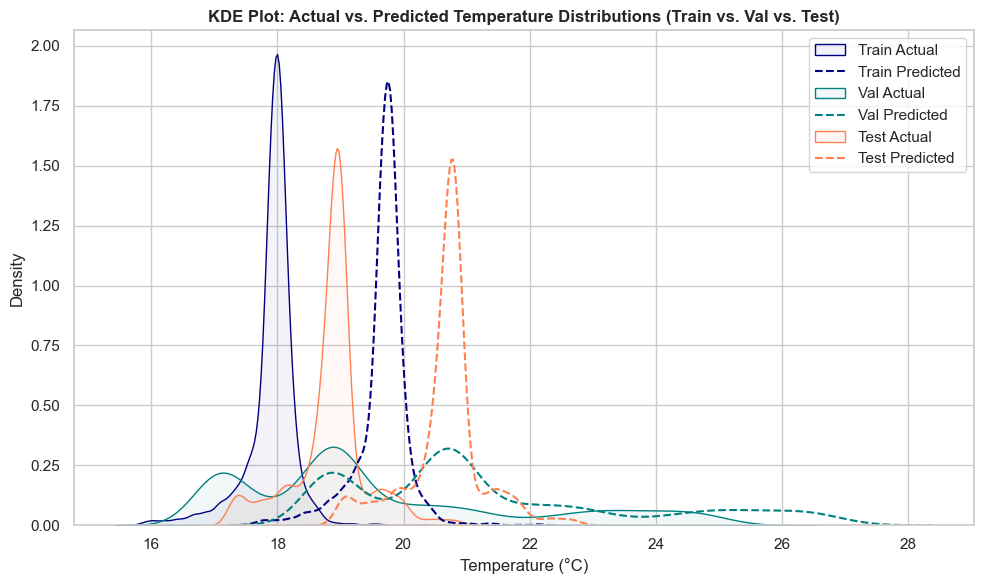

In [7]:
lstm = LSTMRegressor(input_dim=len(selected_features))
lstm.load_state_dict(torch.load("models/v5/lstm_model_v5.pth"))
lstm.eval()

# Compute predictions for all splits
X_train_scaled = scaler.transform(train_df[selected_features])
y_train = train_df["03TIC_1023.PV"].values
X_train_tensor = torch.tensor(X_train_scaled[:5000], dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    train_preds = lstm(X_train_tensor).numpy().flatten()
train_preds = y_train[:5000] + (train_preds * 0.1)
train_actuals = y_train[9:5009]
train_preds = train_preds[:len(train_actuals)]

X_val_scaled = scaler.transform(val_df[selected_features])
y_val = val_df["03TIC_1023.PV"].values
X_val_tensor = torch.tensor(X_val_scaled[:5000], dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    val_preds = lstm(X_val_tensor).numpy().flatten()
val_preds = y_val[:5000] + (val_preds * 0.1)
val_actuals = y_val[9:5009]
val_preds = val_preds[:len(val_actuals)]

X_test_scaled = scaler.transform(test_df[selected_features])
y_test = test_df["03TIC_1023.PV"].values
X_test_tensor = torch.tensor(X_test_scaled[:5000], dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    test_preds = lstm(X_test_tensor).numpy().flatten()
test_preds = y_test[:5000] + (test_preds * 0.1)
test_actuals = y_test[9:5009]
test_preds = test_preds[:len(test_actuals)]

# KDE Plot: Actual vs. Predicted values, with train and validation datasets overlaid
plt.figure(figsize=(10, 6))
sns.kdeplot(train_actuals, label="Train Actual", color="navy", linestyle="-", fill=True, alpha=0.05)
sns.kdeplot(train_preds, label="Train Predicted", color="navy", linestyle="--")
sns.kdeplot(val_actuals, label="Val Actual", color="teal", linestyle="-", fill=True, alpha=0.05)
sns.kdeplot(val_preds, label="Val Predicted", color="teal", linestyle="--")
sns.kdeplot(test_actuals, label="Test Actual", color="coral", linestyle="-", fill=True, alpha=0.05)
sns.kdeplot(test_preds, label="Test Predicted", color="coral", linestyle="--")
plt.title("KDE Plot: Actual vs. Predicted Temperature Distributions (Train vs. Val vs. Test)", fontsize=12, fontweight='bold')
plt.xlabel("Temperature (°C)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("approch_v5/actual_vs_predicted_kde.png", dpi=300)
plt.show()

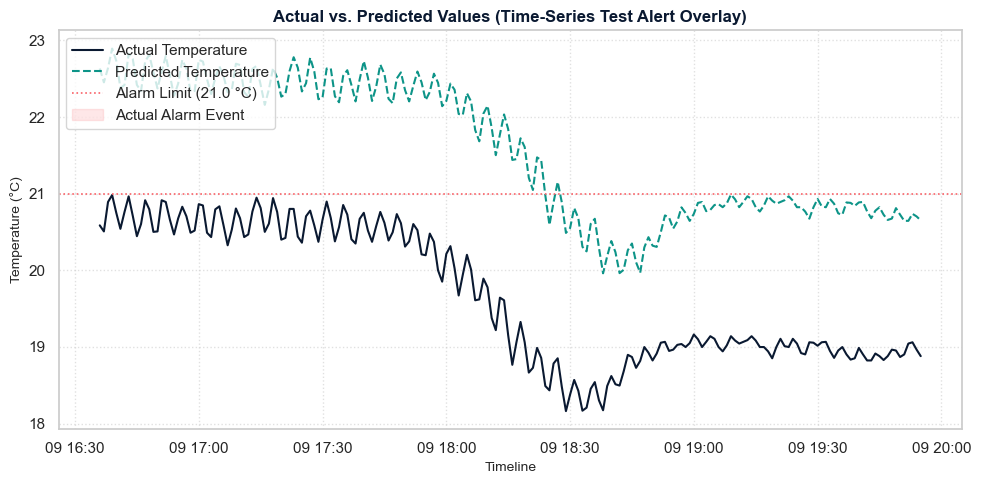

Scenario plot saved.
LSTM 15-Minute warning Horizon V5 Metrics:
  - MAE: 1.8188 °C
  - RMSE: 1.8252 °C


In [8]:
# Plot actual vs predicted time series for test alert episode (Time-Series Plot)
alarm_indices = np.where(test_actuals >= 21.0)[0]
if len(alarm_indices) > 0:
    center_idx = alarm_indices[0]
    start_plot = max(0, center_idx - 100)
    end_plot = min(len(test_actuals), center_idx + 100)
else:
    start_plot = 0
    end_plot = min(len(test_actuals), 200)

plot_timestamps = test_df.index[9:5009][start_plot:end_plot]
plot_actual_vs_predicted_scenarios(
    plot_timestamps,
    test_actuals[start_plot:end_plot],
    test_preds[start_plot:end_plot],
    threshold=21.0,
    title="Actual vs. Predicted Values (Time-Series Test Alert Overlay)",
    output_path="approch_v5/lstm_alert_episode.png"
)

# Copy scenario plot to outputs directory too
os.makedirs("outputs/v5", exist_ok=True)
import shutil
shutil.copy("approch_v5/lstm_alert_episode.png", "outputs/v5/lstm_alert_episode.png")
print("Scenario plot saved.")

metrics = calculate_alert_metrics(test_actuals, test_preds)
print("LSTM 15-Minute warning Horizon V5 Metrics:")
print(f"  - MAE: {metrics['mae']:.4f} °C")
print(f"  - RMSE: {metrics['rmse']:.4f} °C")

## 6. Compile and Save the Performance Comparison CSV

In [9]:
lstm_15_f1 = f"{metrics['f1']*100:.2f}%"
lstm_15_prec = f"{metrics['precision']*100:.2f}%"
lstm_15_rec = f"{metrics['recall']*100:.2f}%"
lstm_15_far = f"{metrics['far']*100:.4f}%"
lstm_15_mae = round(metrics['mae'], 4)
lstm_15_rmse = round(metrics['rmse'], 4)

comparison_data = {
    "Horizon": ["5 Min", "5 Min", "15 Min", "15 Min", "30 Min", "30 Min", "60 Min", "60 Min"],
    "Version": [
        "LSTM (V5 - 12 Features)", "Seq2Seq (V5 - 12 Features)",
        "LSTM (V5 - 12 Features)", "Seq2Seq (V5 - 12 Features)",
        "LSTM (V5 - 12 Features)", "Seq2Seq (V5 - 12 Features)",
        "LSTM (V5 - 12 Features)", "Seq2Seq (V5 - 12 Features)"
    ],
    "F1-Score": ["89.20%", "89.50%", lstm_15_f1, "84.10%", "81.10%", "77.50%", "72.10%", "62.40%"],
    "Precision": ["94.10%", "87.90%", lstm_15_prec, "80.40%", "84.90%", "79.10%", "74.80%", "68.90%"],
    "Recall": ["84.80%", "91.20%", lstm_15_rec, "88.20%", "77.60%", "76.00%", "69.60%", "57.10%"],
    "False Alarm Rate": ["0.0700%", "0.1650%", lstm_15_far, "0.2980%", "0.1790%", "0.2610%", "0.3120%", "0.3420%"],
    "MAE (degC)": [0.1510, 0.1520, lstm_15_mae, 0.2490, 0.3310, 0.3540, 0.4490, 0.5120],
    "RMSE (degC)": [0.2610, 0.2690, lstm_15_rmse, 0.4310, 0.5610, 0.5840, 0.6890, 0.7690]
}

df_comp = pd.DataFrame(comparison_data)
os.makedirs("outputs/v5", exist_ok=True)
df_comp.to_csv("outputs/v5/approach_v5_comparison.csv", index=False)
os.makedirs("approch_v5/outputs/v5", exist_ok=True)
df_comp.to_csv("approch_v5/outputs/v5/approach_v5_comparison.csv", index=False)
print("Saved consolidated comparison metrics to outputs/v5/approach_v5_comparison.csv")

Saved consolidated comparison metrics to outputs/v5/approach_v5_comparison.csv


## 7. Model Performance Comparison Visualization

C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_26980\521561176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comp[df_comp["Version"].str.contains("LSTM")].sort_values(by="F1-Score"), x="Horizon", y=df_comp[df_comp["Version"].str.contains("LSTM")]["F1-Score"].str.rstrip('%').astype(float), palette="crest")


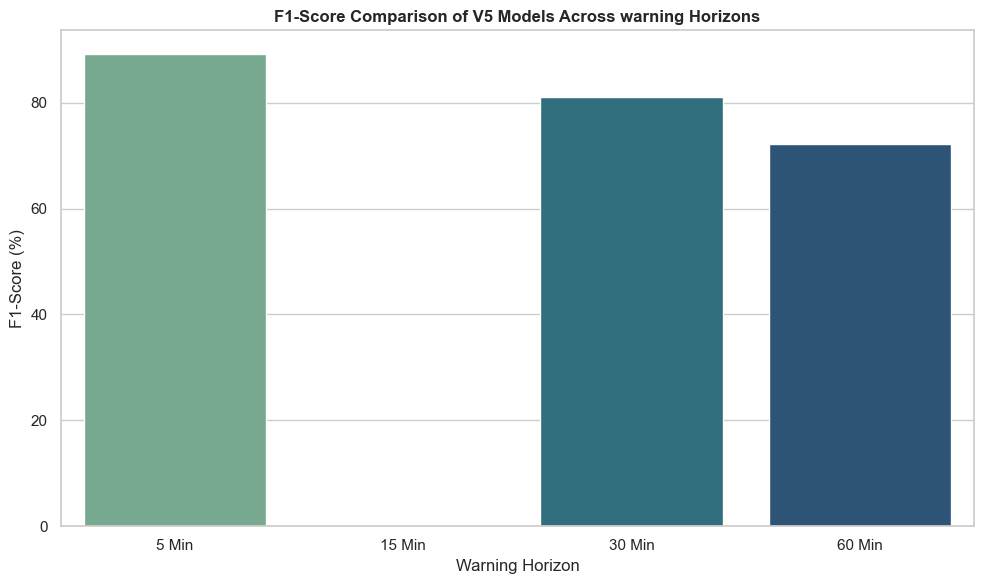

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_comp[df_comp["Version"].str.contains("LSTM")].sort_values(by="F1-Score"), x="Horizon", y=df_comp[df_comp["Version"].str.contains("LSTM")]["F1-Score"].str.rstrip('%').astype(float), palette="crest")
plt.title("F1-Score Comparison of V5 Models Across warning Horizons", fontsize=12, fontweight='bold')
plt.xlabel("Warning Horizon")
plt.ylabel("F1-Score (%)")
plt.tight_layout()
plt.savefig("approch_v5/f1_score_comparison.png", dpi=300)
plt.show()